In [1]:
import cv2
import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, datasets

In [2]:
# ----- Convolution Function -----

In [3]:
def Convolution(image, filter, stride=1, padding=0):
    """
    Implement your own conv function which performs convolution operation without using any neural network packages.
    Make sure to handle all possible edge cases to receive full credits as your implementation will be tested with 20 test cases (1 pt for each test case).
    Keep in mind that height and width of the given image or filter are not always the same.

    Inputs
    - image: 2D numpy array
    - filter: 2D numpy array
    - stride, padding: integers

    Outputs:
    - 2D numpy array : convolution results of the given image and filter..
    - Return None if stride is not compatible. (ex. image of 5*5 with filter 2*2 with stride 2, padding 0)
    - Return None if filter is larger than the given image.
    """
    if padding != 0:
        imagePadded = np.zeros((image.shape[0]+padding*2, image.shape[1]+padding*2))
        imagePadded[padding:(-1*padding), padding:(-1*padding)] = image
        image = imagePadded

    if (image.shape[0]-filter.shape[0] <0) or (image.shape[1]-filter.shape[1] <0) :
        return None
    elif stride == 0:
        return None
    elif ((image.shape[0]-filter.shape[0])%stride != 0) or ((image.shape[1]-filter.shape[1])%stride != 0):
        return None
    else:
        output_height = int((image.shape[0]-filter.shape[0])/stride + 1)
        output_width = int((image.shape[1]-filter.shape[1])/stride + 1)

        output = np.zeros((output_height,output_width))

        for i in range(output_height):
            for j in range(output_width):
                elem = 0
                for k in range(filter.shape[0]):
                    for l in range(filter.shape[1]):
                        elem += filter[k,l]*image[k+(i*stride),l+(j*stride)]
                output[i,j] = elem

        return output

In [4]:
# 확인
Convolution(
    np.array([[1, 2, 3, 2, 1],
              [2, 3, 4, 5, 6],
              [-1, -2, -3, -4, -5],
              [0, 0, 1, 0, 0],
              [7, 1, 7, 1, 7]]),
    np.array([[1, 0],
              [0, 1]]),
    stride=3,
    padding=0
)
## Expected result:
# array([[4., 8.],
#        [1., 7.]])

array([[4., 8.],
       [1., 7.]])

In [5]:
# ----- Utils -----

In [6]:
def plot_dataset(dataloader, grid_width=8, grid_height=2, figure_width=12, figure_height=3, y_hats=None):
    
    images, labels = next(iter(dataloader))
    f, ax = plt.subplots(grid_height, grid_width)
    f.set_size_inches(figure_width, figure_height)
    img_idx = 0
    for i in range(0, grid_height):
        for j in range(0, grid_width):
            image = images[img_idx]
            label = labels[img_idx]
            title_color = 'k'
            if y_hats is None:
                label_idx = int(label)
            else:
                label_idx = int(y_hats[img_idx])
                if int(labels[img_idx]) != label_idx:
                    title_color = 'r'
            label = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'][label_idx]
            ax[i][j].axis('off')
            ax[i][j].set_title(label, color=title_color)
            ax[i][j].imshow(np.transpose(image, (1, 2, 0)), aspect='auto')
            img_idx += 1
        plt.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=0, hspace=0.25)
    
    plt.show()

In [7]:
def train(model, train_loader, optimizer):

    model.train()
    tqdm_bar = tqdm(enumerate(train_loader))
    for batch_idx, (image, label) in tqdm_bar:
        image = image.to(DEVICE)
        label = label.to(DEVICE)
        optimizer.zero_grad()
        output = model(image)
        loss = criterion(output, label)
        loss.backward()
        optimizer.step()
        tqdm_bar.set_description("Epoch {} - train loss: {:.6f}".format(epoch, loss.item()))


def evaluate(model, test_loader):

    model.eval()
    test_loss = 0
    correct = 0

    with torch.no_grad():
        for image, label in tqdm(test_loader):
            image = image.to(DEVICE)
            label = label.to(DEVICE)
            output = model(image)
            test_loss += criterion(output, label).item()
            prediction = output.max(1, keepdim=True)[1]
            correct += prediction.eq(label.view_as(prediction)).sum().item()
    
    test_loss /= len(test_loader.dataset)
    test_accuracy = 100. * correct / len(test_loader.dataset)
    return test_loss, test_accuracy

In [8]:
# ----- CIFAR-10 Data Augmentation -----
# input image shape: (32,32,3)

In [9]:
def gaussian_smoothing(image, filter_size=3, sigma=1.0):

    center = (filter_size-1)/2
    gaussian_filter = np.zeros((filter_size, filter_size))
    for row in range(filter_size):
        for col in range(filter_size):
            gaussian_filter[row, col] = np.exp((-(row-center) ** 2 - (col-center) ** 2) / (2 * sigma ** 2)) / (2 * np.pi * sigma ** 2)
    gaussian_filter = gaussian_filter / np.sum(gaussian_filter)
    image = cv2.filter2D(image, -1, gaussian_filter) # 필터 적용

    return image


def color_jitter(image):

    image = cv2.convertScaleAbs(image, alpha=1.5, beta=20)

    return image


def custom_augmentation(image): 
#     1. Rotate 
#     width = image.shape[0]
#     height = image.shape[1]
#     rotation_matrix = cv2.getRotationMatrix2D((width/2,height/2),45,.5)
#     image = cv2.warpAffine(image,rotation_matrix,(width,height))
#.    2. Flip 
    image = cv2.flip(image,3)

    return image

In [10]:
# 확인
raw_test = datasets.CIFAR10(root="./data/CIFAR_10", train=False, download=True)

Files already downloaded and verified


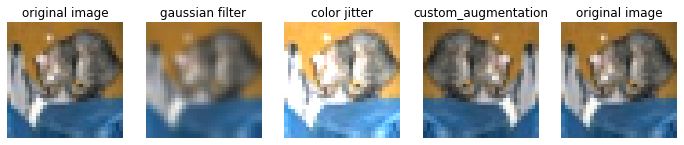

In [11]:
# matplotlib의 imshow를 쓸 때 커널이 죽는 경우 사용
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

f, ax = plt.subplots(1, 5)
f.set_size_inches(12, 3)
x = raw_test[0][0]
x = np.array(x)
g = gaussian_smoothing(x)
j = color_jitter(x)
c = custom_augmentation(x)
title = ['original image', 'gaussian filter', 'color jitter', 'custom_augmentation', 'original image']
for i, img in enumerate([x, g, j, c, x]):
    ax[i].imshow(img)
    ax[i].axis('off')
    ax[i].set_title(title[i], color='k')

In [12]:
# ----- Load dataset -----

In [13]:
class CustomDataset(Dataset):
    def __init__(self, train, prob=0.5, data_dir="./data/CIFAR_10"):

        self.data = datasets.CIFAR10(root=data_dir, train=train, download=True)
        self.prob = prob

        
    def __len__(self):
        return len(self.data)
    
    
    def __getitem__(self, idx):
        return self.data[idx]
    
    
    def transform(self, image):

        image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR) # Convert the given RGB image into BGR scale
        
        if prob != 0:
            if np.random.rand() > prob :
                func = np.random.randint(3)
                aug = ['gaussian_smoothing', 'color_jitter', 'custom_augmentation']
                image = aug[func](image)
                
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # Convert the augmented image back to RGB scale for training
        
        return image

    def collate_fn(self, data):
        """
        Inputs
        - list of tuples, each containing a PIL image and an integer label
        - number of tuples in the list == BATCH SIZE
        Returns
        - batch of image tensors, batch of label tensors
        - size: (BATCH, CHANNEL, HEIGHT, WIDTH), (BATCH)
        """
        batch_x, batch_y = [], []
        
        for x, y, in data:
#             if self.transform is not None: # Transform the image using self.transform method to apply random augmentation
#                 x = self.transform(x)
            x = np.array(x)/255 # Convert each image in the batch from PIL image to numpy array & Normalize the transformed image by mapping the range [0, 255] to range [0, 1]
            x = torch.Tensor([x]) # Convert the batch of preprocessed images into PyTorch float tensors
            x = x.view([3, 32, 32])# (H * W * C) to (C * H * W)
            y = torch.Tensor([y]) # Convert the batch of labels into PyTorch long tensors
            batch_x.append(x)
            batch_y.append(y)      
        # batch_x, batch_y를 list에서 tensor로 바꾸기
        batch_x = torch.stack(batch_x).float()
        batch_y = torch.cat(batch_y).long()

        return batch_x, batch_y

In [20]:
raw_test_dataset = CustomDataset(train=False, prob=0, data_dir="./data/CIFAR_10")
raw_test_loader = DataLoader(dataset=raw_test_dataset, 
                             batch_size=16, 
                             shuffle=False)

Files already downloaded and verified


In [26]:
a = raw_test_dataset[0][0]
type(a)

PIL.Image.Image

In [27]:
image = cv2.cvtColor(a, cv2.COLOR_RGB2BGR)
image

error: OpenCV(4.6.0) :-1: error: (-5:Bad argument) in function 'cvtColor'
> Overload resolution failed:
>  - src is not a numpy array, neither a scalar
>  - Expected Ptr<cv::UMat> for argument 'src'


In [21]:
batch_x, batch_y = next(iter(raw_test_loader))
batch_x[0]

TypeError: default_collate: batch must contain tensors, numpy arrays, numbers, dicts or lists; found <class 'PIL.Image.Image'>

Files already downloaded and verified


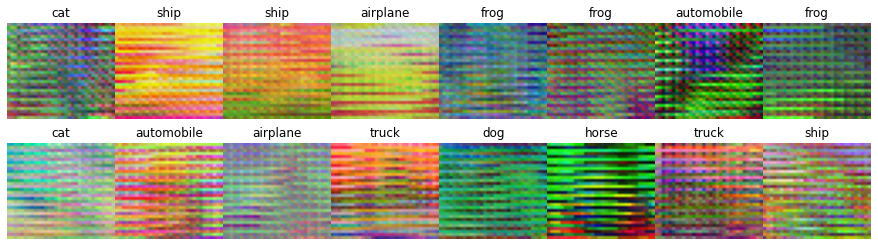

In [14]:
# without applying data augmentation
raw_test_dataset = CustomDataset(train=False, prob=0, data_dir="./data/CIFAR_10")
raw_test_loader = DataLoader(dataset=raw_test_dataset, 
                             batch_size=16, 
                             shuffle=False, 
                             collate_fn=raw_test_dataset.collate_fn)

plot_dataset(raw_test_loader)

In [ ]:
# after applying data augmentation with 50% probability
train_dataset = CustomDataset(train=True, prob=0.5)
test_dataset = CustomDataset(train=False, prob=0.5)

BATCH_SIZE = 64

train_loader = DataLoader(dataset=train_dataset, 
                          batch_size=BATCH_SIZE, 
                          shuffle=True, 
                          collate_fn=train_dataset.collate_fn)
test_loader = DataLoader(dataset=test_dataset, 
                         batch_size=BATCH_SIZE, 
                         shuffle=False, 
                         collate_fn=test_dataset.collate_fn)

plot_dataset(test_loader)

In [ ]:
# ConvNet Image Classification

In [ ]:
### 
# Question (e)
# Train your ConvNet to achieve test accuracy above 60%
# You can try or add other training options such as SGD or callbacks to schedule learning rates if you want.
###

In [ ]:
class ConvNet(nn.Module):
    """
    Builds a ConvNet model.

    Question (e)
    - things that might be useful...
    - stack [Conv2D + Conv2D + MaxPool2D] at least three times, 
    - follwed by at least three Linear layers.
    - 3x3 filter is enough, but feel free to use larger filter size.
    - channels used: [10, 32, 64, 128, 256, 512, 1024]
    - you can choose smaller or larger channel size as well.
    - The model may include BatchNormalization, regularizers, and Dropout, but they are not necessary.
    """
    def __init__(self):
        """
        Define the layers that you would like to use in your model.
        """
        super(ConvNet, self).__init__()

        ### COMPLETE HERE ###

        ### COMPLETE HERE ###
    
    def forward(self, x):
        """
        Apply forward pass of the given batch of input images.
        Inputs
        - x: batch of input images.
        Returns
        - softmax probabilites of the input image for each class label
        """

        ### COMPLETE HERE ###
        
        ### COMPLETE HERE ###

        return x

In [ ]:
"""
Make sure your runtime type is GPU and you are using PyTorch version higher than 1.8!

Do NOT modify.
"""

DEVICE = torch.device('cuda') if torch.cuda.is_available else torch.device('cpu')
print("Using PyTorch version: {}, Device: {}".format(torch.__version__, DEVICE))

In [ ]:
"""
Load your customized model "ConvNet" and its training settings.
You may choose the number of epochs that you would like to train.
You might want to use different optimizers or learning rates.
"""

EPOCHS = 10
model = ConvNet().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

print(model)

In [ ]:
"""
Train your model "ConvNet" with the augmented CIFAR-10 dataset.
Upon successful training, test accuracy of your model should be above 70%.

Do NOT modify.
"""

for epoch in range(1, EPOCHS + 1):
    train(model, train_loader, optimizer)
    test_loss, test_accuracy = evaluate(model, test_loader)
    print("\n[EPOCH: {}], \tModel: ConvNet, \tTest Loss: {:.4f}, \tTest Accuracy: {:.2f} % \n".format(
        epoch, test_loss, test_accuracy))